## DATA 622 - Assignment 4: Final Project

### Assignment:

- Choose a dataset. You get to decide which dataset you want to work on. The data set must be different from the ones used in previous homeworks You can work on a problem from your job, or something you are interested in. You may also obtain a dataset from sites such as Kaggle, Data.Gov, Census Bureau, USGS or other open data portals. 
- Select one of the methodologies studied in weeks 1-10, and another methodology from weeks 11-15 to apply in the new dataset selected.
- To complete this task:
    - Describe the problem you are trying to solve.
    - Describe your dataset and what you did to prepare the data for analysis. 
    - Methodologies you used for analyzing the data
    - What's the purpose of the analysis performed
    - Make your conclusions from your analysis. Please be sure to address the business impact (it could be of any domain) of your solution.

### Deliverables
Your final presentation (essay or video) should include:
- The traditional R file or Python file and essay,
- An Essay (minimum 500 word document) or Video ( 5 to 8 minutes recording). Include the execution and explanation of your code. The video can be recorded on any platform of your choice (Youtube, Free Cam).

### Introduction

Stock price prediction is a widely adopted practice in the finance industry for many years, offering valuable insights to investors and financial institutions. By anticipating future stock returns, financial professionals can allocate limited resources more efficiently, hedge against potential losses, and capitalize on emerging opportunities that might otherwise be overlooked. Recent advancements in machine learning have introduced modern regression models based on deep learning techniques, such as Deep Quantile Regression. 

Deep Quantile Regression is the extension of Quantile Regression that predict multiple conditional quantiles including the median of the target variable. It leverages deep neural networks to capture complex and non-linear relationships between the target and response variable. This approach predicts point estimates as well as construct prediction intervals, which can offer valuable insights into the uncertainty and potential risk of price forecasts. 

For this assignment, the purpose is to explore the application of Deep Quantile Regression for stock price prediction. The primary data source is the historical daily stock price data for a selected group of publicly traded companies and will be obtained from Yahoo Finance. The selected companies are the top 25 companies of the S&P 500 index, based on the market capitalization as it captures a diverse representation of different industries. The performance of Deep Quantile Regression on historical stock price data will be evaluated to determine whether Deep Quantile Regression provides a meaningful improvement in predictive accuracy and uncertainty quantification, and whether its application to stock price prediction is a worthwhile advancement.

In [16]:
# load packages for stock data pulling and preprocessing
import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import warnings
import matplotlib.pyplot as plt
import datetime as dt
import plotly.express as px
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
from pandas.plotting import table

# load packages for deep quantile regression
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# warnings.filterwarnings('ignore')

### Data Pulling

In [ ]:
# define the top 25 companies in the S&P 500 by weight based on the link below: https://www.slickcharts.com/sp500
ticker_list = ['NVDA', 'MSFT', 'AAPL', 'AMZN', 'META',
                'AVGO', 'GOOGL', 'TSLA', 'JPM', 'ORCL', 
                'WMT', 'LLY', 'V', 'MA', 'NFLX', 
                'XOM', 'JNJ', 'ABBV', 'PLTR', 'COST', 
                'HD', 'BAC', 'PG', 'UNH', 'GE']

# set the date interval of 10 years (March 2015 - April 2025)
start_date = datetime.datetime(2015, 3, 31)
end_date = datetime.datetime(2025, 4, 30)

# download the data from Yfinance
data = yf.download(ticker_list, start=start_date, end=end_date, auto_adjust=False, group_by='ticker')
    
# change the multiIndex format to single column data frame for ease of usage
fin_tidy_data = data.stack(level=0).reset_index()
fin_tidy_data = fin_tidy_data.rename(columns={'level_1': 'Ticker'})
fin_tidy_data['Date'] = pd.to_datetime(fin_tidy_data['Date'])
fin_tidy_data = fin_tidy_data.sort_values(by=['Ticker', 'Date'])

[*********************100%***********************]  25 of 25 completed


Price
Date         datetime64[ns]
Ticker               object
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume              float64
dtype: object

### Exploratory Data Analysis

In [12]:
# check the data type
fin_tidy_data.dtypes

Price
Date         datetime64[ns]
Ticker               object
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume              float64
dtype: object

In [15]:
# check for missing or null data
print(fin_tidy_data.isnull().sum())

for col in fin_tidy_data.columns:
    print(f"{col}: {fin_tidy_data[col].value_counts().get('unknown', 0)} unknowns")

Price
Date         0
Ticker       0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Date: 0 unknowns
Ticker: 0 unknowns
Adj Close: 0 unknowns
Close: 0 unknowns
High: 0 unknowns
Low: 0 unknowns
Open: 0 unknowns
Volume: 0 unknowns


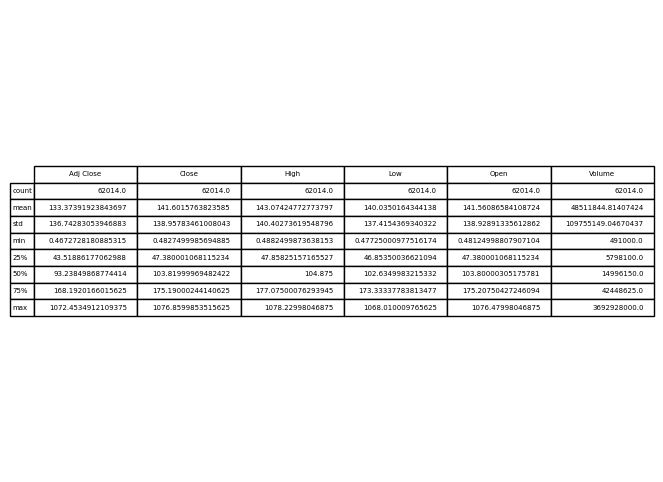

In [18]:
# descriptive statistics
summary_table = fin_tidy_data.describe()

# create a subplot without frame
plt.figure(figsize=(8, 6))
plot = plt.subplot(111, frame_on=False)

# remove axis
plot.xaxis.set_visible(False) 
plot.yaxis.set_visible(False) 

# create the table plot and position it in the upper left corner
table(plot, summary_table,loc='center')

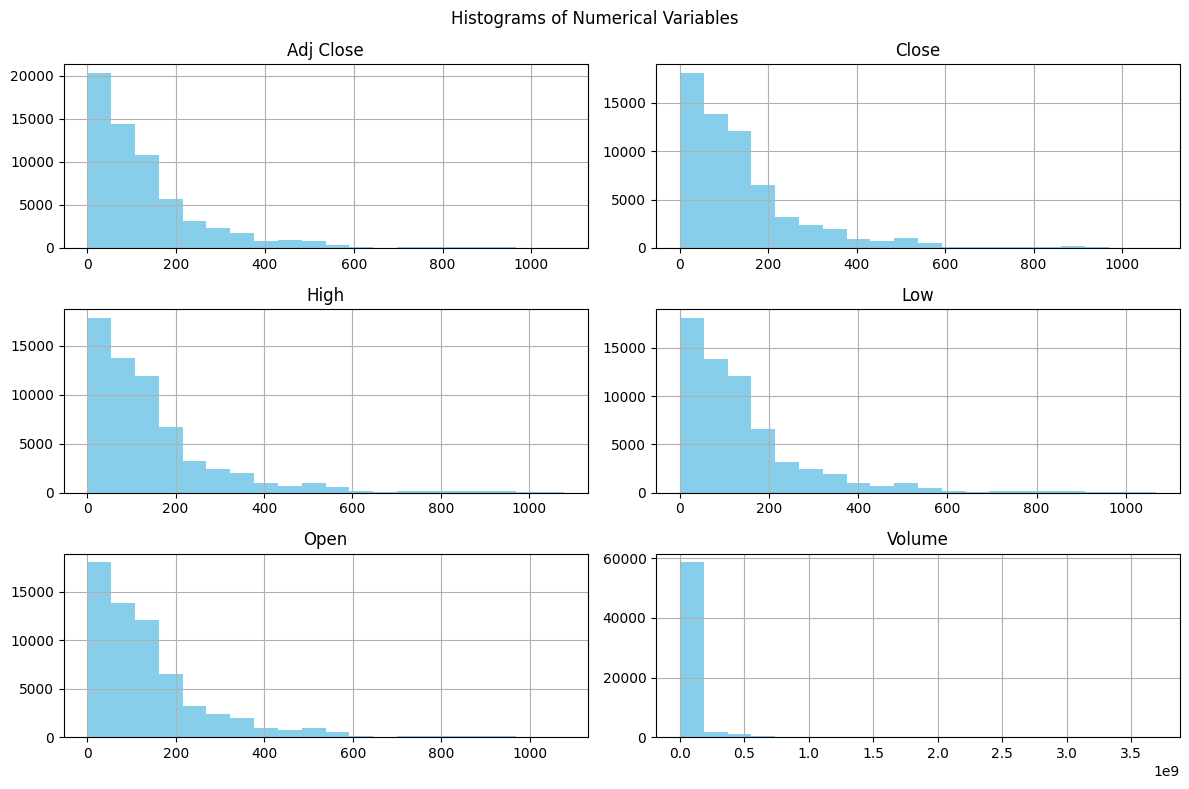

In [19]:
# histogram on numerical variables
num_cols = fin_tidy_data.select_dtypes(include=np.number).columns.tolist()
fin_tidy_data[num_cols].hist(bins=20, figsize=(12, 8), color='skyblue')
plt.suptitle("Histograms of Numerical Variables")
plt.tight_layout()
plt.show()

### Insights and Observations
Once the data was successfully obtained, an exploratory data analysis was performed to assess data qualities and gain data insights before facilitating the model development and evaluation. The dataset covers the period from March 2015 to April 2025, and it comprises of 62,014 observations. In addition, the dataset has no missing or null values. The descriptive statistic was applied on the numerical variables to understand their distributional properties. The results below show that the mean values are relatively high, which can be attributed to the presence of companies with large market capitalizations such as, Apple and Amazon, in the dataset. The statistics also reveal a wide range across all variables. This indicates that there is a heteroscedasticity since the data appears to be highly volatile and non-stationary. In addition, the mean is larger than the median for all variables, which indicates each distribution may be right-skewed and have a long tail on the high end, especially `Volume` variable. This interpretation is further supported by the standard deviation being larger compared to the mean, showing that the data is very spread out. The histogram below reinforces the finding as it shows each distribution is indeed right skewed. 

### Data Pre-Processing
Due to the findings identified during the exploratory data analysis, the original variables were not suitable as features for Deep Quantile Regression models. Because of that, the dataset was preprocessed for model development and evaluation. Multiple features were engineered to address problems such as the skewness observed in original variables. There are missing data for some of the features because they depend on prior observations that fall outside the available dataset. This resulted in incomplete sequences at the beginning or end of the dataset. To address this, missing values were imputed using a combination of forward-fill and backward-fill methods. Furthermore, all features were scaled to ensure that they contributed equally during the model training. The dataset was later divided into three subsets: 70% for training, 15% for hyperparameter tuning, and the remaining 15% for final performance evaluation.

The model used the engineered features as input variables as they were fed into the feedforward neural network with 2 hidden layers, and the target variable was the adjusted closing price for future time horizons of 30 days. In addition, the model was applied with monotonicity constraints to avoid the quantile crossing and ensure that the estimated quantiles are ordered properly. For evaluation, the was evaluated based on multiples quantiles (0.1, 0.5, 0.9, 0.99) with the following metrics:
- ***Pinball Loss or Quantile Loss:*** the evaluation metric that is specifically designed for Deep Quantile Regression. It measures how well the predicted quantiles align with the actual outcomes
- ***Prediction Interval Coverage Probability:*** the evaluation metric that measures the reliability of prediction intervals for Deep Quantile Regression

In [21]:
# define a data pre-processing function
def stock_preprocessing(data):

    # calculate the lagged return
    data['Lagged_Returns'] = data.groupby('Ticker')['Adj Close'].shift(1).pct_change(fill_method = None) 

    # calculate the 1-day forward return
    data['Return_1d'] = data.groupby('Ticker')['Adj Close'].pct_change()

    # calculate the 5-days forward return
    data['Return_5d'] = data.groupby('Ticker')['Adj Close'].pct_change(5)

    # calculate the 5 and 21 Days rolling standard deviation
    data['Volatility_5d'] = data.groupby('Ticker')['Return_1d'].rolling(5).std().reset_index(level=0, drop=True)
    data['Volatility_21d'] = data.groupby('Ticker')['Return_1d'].rolling(21).std().reset_index(level=0, drop=True)

    # calculate the relative strength index (RSI) of past 14 periods with EMA smoothing to provide weighted average.
    rsi_window = 14
    delta = data.groupby('Ticker')['Adj Close'].transform(lambda x: x.diff())
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.groupby(data['Ticker']).transform(lambda x: x.ewm(alpha=1/rsi_window, min_periods=rsi_window).mean())
    avg_loss = loss.groupby(data['Ticker']).transform(lambda x: x.ewm(alpha=1/rsi_window, min_periods=rsi_window).mean())
    rs = avg_gain / avg_loss
    rs = avg_gain / avg_loss
    rs = rs.replace([np.inf, -np.inf], np.nan)
    data['RSI'] = 100 - (100 / (1 + rs))

    # fill out nan values for RSI edge cases
    data['RSI'] = data['RSI'].fillna(50)

    # calculate the simple moving average (SMA)
    sma_window = 20
    data['SMA_20'] = data.groupby('Ticker')['Adj Close'].transform(lambda x: x.rolling(window=sma_window).mean())

    # calculate the moving average convergence divergence
    ema12 = data.groupby('Ticker')['Adj Close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
    ema26 = data.groupby('Ticker')['Adj Close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
    data['MACD'] = ema12 - ema26

    # calculate the simple moving average ratio
    data['SMA20_Ratio'] = data['Adj Close'] / data['SMA_20']
    data['SMA20_Ratio'] = data['SMA20_Ratio'].replace([np.inf, -np.inf], np.nan)

    # calculate the log of trading volume
    data['log_Volume'] = np.log1p(data['Volume'])

    # fill missing data using forward and backward fill methods and 
    fill_cols = ['Lagged_Returns', 'Return_1d', 'Return_5d', 'Volatility_5d', 'Volatility_21d',
                'RSI', 'SMA_20', 'MACD', 'SMA20_Ratio']
    data[fill_cols] = data.groupby('Ticker')[fill_cols].transform(lambda x: x.bfill().ffill())

    data = data.replace([np.inf, -np.inf], np.nan)
    data = data.fillna(0)

    return data

# run the function
pre_process_data = stock_preprocessing(fin_tidy_data)
pre_process_data.head(10)

Price,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Lagged_Returns,Return_1d,Return_5d,Volatility_5d,Volatility_21d,RSI,SMA_20,MACD,SMA20_Ratio,log_Volume
0,2015-03-31,AAPL,27.693964,31.107500,31.622499,31.090000,31.522499,168362400.0,-0.001447,-0.001447,0.009403,0.010507,0.012397,50.0,28.307802,0.000000,1.026512,18.941629
24,2015-04-01,AAPL,27.653894,31.062500,31.280001,30.775000,31.205000,162485600.0,-0.001447,-0.001447,0.009403,0.010507,0.012397,50.0,28.307802,-0.003196,1.026512,18.906100
48,2015-04-02,AAPL,27.892050,31.330000,31.389999,31.047501,31.257500,128880400.0,-0.001447,0.008612,0.009403,0.010507,0.012397,50.0,28.307802,0.013334,1.026512,18.674395
72,2015-04-06,AAPL,28.343851,31.837500,31.877501,31.082500,31.117500,148776000.0,0.008612,0.016198,0.009403,0.010507,0.012397,50.0,28.307802,0.062174,1.026512,18.817952
96,2015-04-07,AAPL,28.045620,31.502501,32.029999,31.495001,31.910000,140049200.0,0.016198,-0.010522,0.009403,0.010507,0.012397,50.0,28.307802,0.075940,1.026512,18.757504
120,2015-04-08,AAPL,27.954361,31.400000,31.600000,31.242500,31.462500,149316800.0,-0.010522,-0.003254,0.009403,0.010507,0.012397,50.0,28.307802,0.078580,1.026512,18.821581
144,2015-04-09,AAPL,28.168034,31.639999,31.645000,31.165001,31.462500,129936000.0,-0.003254,0.007644,0.018592,0.010565,0.012397,50.0,28.307802,0.096798,1.026512,18.682553
168,2015-04-10,AAPL,28.288214,31.775000,31.802500,31.315001,31.487499,160752000.0,0.007644,0.004267,0.014203,0.010237,0.012397,50.0,28.307802,0.119555,1.026512,18.895373
192,2015-04-13,AAPL,28.232573,31.712500,32.142502,31.652500,32.092499,145460400.0,0.004267,-0.001967,-0.003926,0.007051,0.012397,50.0,28.307802,0.131584,1.026512,18.795414
216,2015-04-14,AAPL,28.110163,31.575001,31.822500,31.477501,31.750000,102098400.0,-0.001967,-0.004336,0.002301,0.005215,0.012397,50.0,28.307802,0.129744,1.026512,18.441448


### Model Training

In [22]:
# define the monotonic deep quantile regression to address the quantile crossing issue
def build_monotonic_dqr_model(input_dim, quantiles=[0.1,0.5,0.9,0.99]):
    
    inp = tf.keras.Input(shape=(input_dim,))
    
    h = tf.keras.layers.Dense(64, activation='relu')(inp)
    h = tf.keras.layers.Dense(32, activation='relu')(h)

    # set the ase quantile q10
    q10 = tf.keras.layers.Dense(1, name="q10")(h)

    # define the increments for higher quantiles
    d50 = tf.keras.layers.Dense(1, activation=tf.nn.softplus, name="d50")(h)
    d90 = tf.keras.layers.Dense(1, activation=tf.nn.softplus, name="d90")(h)
    d99 = tf.keras.layers.Dense(1, activation=tf.nn.softplus, name="d99")(h)

    q50 = q10 + d50
    q90 = q50 + d90
    q99 = q90 + d99

    outputs = tf.keras.layers.Concatenate(name="quantiles")([q10, q50, q90, q99])

    model = tf.keras.Model(inputs=inp, outputs=outputs)

    return model

# define the quantile loss function
def multi_quantile_loss(quantiles):
    def loss(y_true, y_pred):
        losses = []
        for i, q in enumerate(quantiles):
            e = y_true - y_pred[:, i]
            losses.append(tf.reduce_mean(tf.maximum(q*e, (q-1)*e)))
        return tf.reduce_sum(losses)
    return loss

# define the deep quantile regression
def deep_quantile_regression(data):

    # define features and quantiles
    features = ['Lagged_Returns', 'Return_1d', 'Return_5d', 'Volatility_5d', 'Volatility_21d',
                'RSI', 'SMA_20', 'MACD', 'SMA20_Ratio', 'log_Volume']
    
    quantiles=[0.1, 0.5, 0.9, 0.99]

    # define x and y variables
    x = data[features].values
    y_raw = data['Adj Close'].values.reshape(-1,1)

    # scale the target variables
    y_scaler = StandardScaler()
    y = y_scaler.fit_transform(y_raw).flatten()

    ticker_labels = data['Ticker'].values
    dates = data['Date'].values if 'Date' in data.columns else np.arange(len(data))

    # split train data into 70% for training and 30% for tuning and performance
    x_train, x_temp, y_train, y_temp, ticker_train, ticker_temp, date_train, date_temp = train_test_split(
        x, y, ticker_labels, dates, test_size=0.3, random_state=42)

    # split the 30% for tuning and performance into 15% validation and 15% test
    x_val, x_test, y_val, y_test, ticker_val, ticker_test, date_val, date_test = train_test_split(
        x_temp, y_temp, ticker_temp, date_temp, test_size=0.5, random_state=42)

    # normalize the data
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    x_val_scaled = scaler.transform(x_val)

    # build the monotonic model
    models = build_monotonic_dqr_model(input_dim=x_train_scaled.shape[1], quantiles=quantiles)

    models.compile(optimizer='adam', loss=multi_quantile_loss(quantiles))

    # train the model
    models.fit(x_train_scaled, y_train,
               validation_data=(x_val_scaled, y_val),
               epochs=40,
               batch_size=32,
               verbose=1)
    
    # predict the value using the test set
    preds_scaled = models.predict(x_test_scaled)\

    # inverse transform the prediction
    preds = y_scaler.inverse_transform(preds_scaled)
    y_test_orig = y_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    quantile_metrics = {}

    for i, q in enumerate(quantiles):
        pred_q = preds[:, i]
        e = y_test_orig - pred_q
        ql = np.mean(np.maximum(q*e, (q-1)*e))

        picp = np.mean(y_test_orig <= pred_q)
        quantile_metrics[q] = {"Quantile Loss": round(float(ql),6), "PICP": round(float(picp),4)}
        print(f"✓ Quantile {q}: Loss={ql:.6f}, PICP={picp:.4f}")

    # calculate the PICP
    lower = preds[:, 0]
    upper = preds[:, 2]
    interval_picp = np.mean((y_test_orig >= lower) & (y_test_orig <= upper))
    print('Interval (Q10-Q90) PICP: ', round(float(interval_picp),4))

    return models, quantile_metrics, interval_picp

In [23]:
models, metrics, interval_picp = deep_quantile_regression(pre_process_data)
for key, value in metrics.items():
    print(f"{key}: {value}")

# print the summary metric
summary_metric_quantile = (pd.DataFrame.from_dict(metrics, orient='index').reset_index().rename(columns={'index':'Quantile'}))


Epoch 1/40
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0880 - val_loss: 0.0322
Epoch 2/40
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 879us/step - loss: 0.0254 - val_loss: 0.0206
Epoch 3/40
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 884us/step - loss: 0.0176 - val_loss: 0.0206
Epoch 4/40
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 912us/step - loss: 0.0131 - val_loss: 0.0131
Epoch 5/40
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 882us/step - loss: 0.0106 - val_loss: 0.0127
Epoch 6/40
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step - loss: 0.0089 - val_loss: 0.0088
Epoch 7/40
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 917us/step - loss: 0.0075 - val_loss: 0.0068
Epoch 8/40
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 879us/step - loss: 0.0067 - val_loss: 0.0081
Epoch 9/40
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step - loss: 0.0063 - val_loss: 0.0067
Epoch 10/40
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 907us/step - loss: 0.0060 - val_loss: 0.0065
Epoch 11/40
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 935us/step - loss: 0.0052 - val_loss: 0.0060
Epoch 12/4

### Discussion of Results

The values from Quantile Loss show that the model has high accuracy precision at the extremes of the distribution (0.1, 0.99). However, the accuracy is lower in the central quantiles (0.5, 0.9), indicating that the model may underestimated the variability. This is further evidenced by the PICP values, where the tail end quantiles have coverages close to their expected values. In addition, the model predicts values that are too low or too narrow in the middle of the distribution.

In conclusion,the Deep Quantile Regression provides a comprehensive view of the full distribution of future stock returns by predicting multiple quantiles. In additon, the evaluation metrics show that the model not only delivers competitive accuracy as well as excels at modeling tail risks. These advantages makes the Deep Quantile Regression a vialable alternatives in stock price forcasting.